# Step 2: Preprocessing

**Goal:** turn the continuous raw recordings into clean, fixed-size trials that EEGNet can learn from.

```
Raw GDF (25 ch, continuous)
      │
      ▼  A. Remove EOG channels         25 → 22 channels (keep brain signals only)
      ▼  B. Band-pass filter 8–30 Hz    keep mu (8–13 Hz) + beta (13–30 Hz) rhythms
      ▼  C. Epoching                    4 s after each cue → 288 trials × 22 ch × 1000 samples
      ▼
X: (288, 22, 1000), y: (288,)   per subject
```

The same code lives in `src/preprocess.py`, so Step 3 uses exactly this pipeline.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data import CLASS_NAMES, cue_events, load_raw
from preprocess import H_FREQ, L_FREQ, TMAX, TMIN, make_epochs, preprocess_raw, save_all

mne.set_log_level("ERROR")
FIG_DIR = Path.cwd().parent / "results" / "figures"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

raw = load_raw("A01", "T")
print(f"Loaded A01T: {len(raw.ch_names)} channels, {raw.info['sfreq']:.0f} Hz, {raw.times[-1] / 60:.1f} min")

Loaded A01T: 25 channels, 250 Hz, 44.8 min


## A. Remove the EOG channels
The 3 EOG channels record **eye movements**, not brain activity. Our model input is the 22 EEG channels only.

In [2]:
raw_eeg = raw.copy().pick("eeg")
print(f"Before: {len(raw.ch_names)} channels  (22 EEG + 3 EOG)")
print(f"After : {len(raw_eeg.ch_names)} channels  -> {raw_eeg.ch_names}")

Before: 25 channels  (22 EEG + 3 EOG)
After : 22 channels  -> ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']


## B. Band-pass filter 8–30 Hz
Motor imagery changes the power of the **mu (8–13 Hz)** and **beta (13–30 Hz)** rhythms over the motor cortex (event-related desynchronization, ERD). The filter keeps this band and removes:
- slow drifts and eye/movement artifacts (< 8 Hz)
- muscle noise and high-frequency interference (> 30 Hz)

We use a zero-phase FIR filter (MNE default), so the signal is not shifted in time.

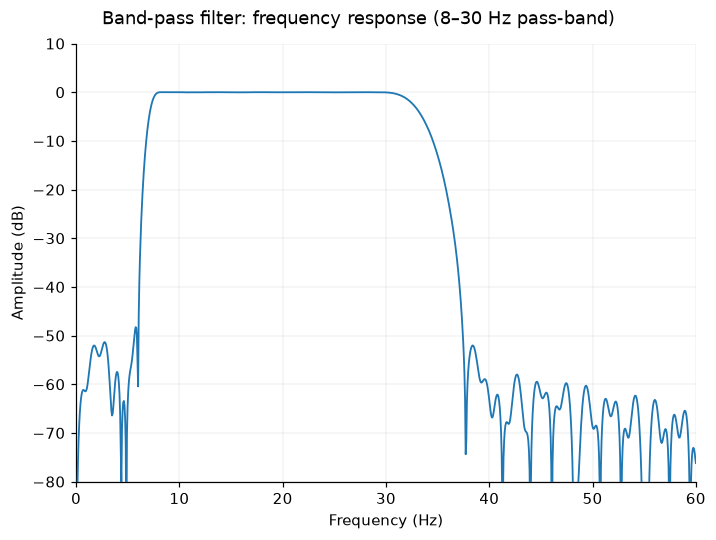

In [3]:
raw_filt = raw_eeg.copy().filter(L_FREQ, H_FREQ, method="fir", phase="zero")

# The filter's frequency response
filt = mne.filter.create_filter(raw_eeg.get_data()[:1, :5000], raw_eeg.info["sfreq"], L_FREQ, H_FREQ,
                                method="fir", phase="zero", verbose="ERROR")
fig = mne.viz.plot_filter(filt, raw_eeg.info["sfreq"], freq=None, gain=None, fscale="linear",
                          flim=(0, 60), plot=("magnitude",), show=False)
fig.suptitle("Band-pass filter: frequency response (8–30 Hz pass-band)")
fig.savefig(FIG_DIR / "02_filter_response.png", bbox_inches="tight")
plt.show()

### Before vs after filtering: time domain (channel C3, one trial)

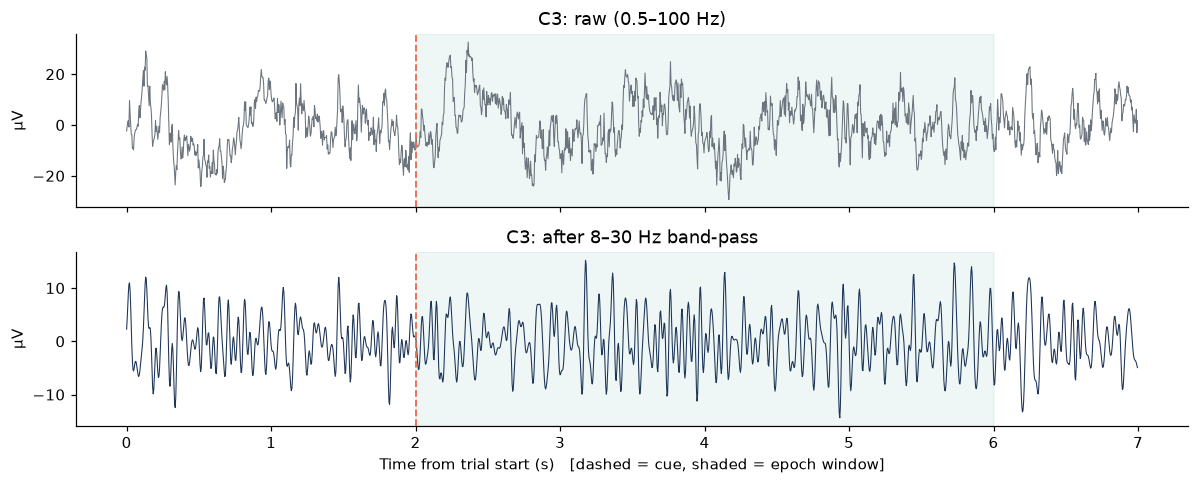

In [4]:
events, event_id = cue_events(raw_eeg)
sf = raw_eeg.info["sfreq"]
cue = events[0, 0]
start, stop = int(cue - 2 * sf), int(cue + 5 * sf)
t = (np.arange(start, stop) - cue) / sf + 2        # time from trial start

before = raw_eeg.get_data(picks="C3", start=start, stop=stop)[0] * 1e6
after = raw_filt.get_data(picks="C3", start=start, stop=stop)[0] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True)
axes[0].plot(t, before - before.mean(), lw=0.7, color="#6c757d"); axes[0].set_title("C3: raw (0.5–100 Hz)")
axes[1].plot(t, after, lw=0.7, color="#1d3557"); axes[1].set_title("C3: after 8–30 Hz band-pass")
for ax in axes:
    ax.axvline(2, color="#e76f51", ls="--", lw=1.2); ax.axvspan(2, 6, color="#2a9d8f", alpha=0.08)
    ax.set_ylabel("µV")
axes[1].set_xlabel("Time from trial start (s)   [dashed = cue, shaded = epoch window]")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_filter_time_domain.png", bbox_inches="tight")
plt.show()

### Before vs after filtering: frequency domain
Power spectrum of the 288 trial windows (2–6 s), averaged over trials and the 22 EEG channels.

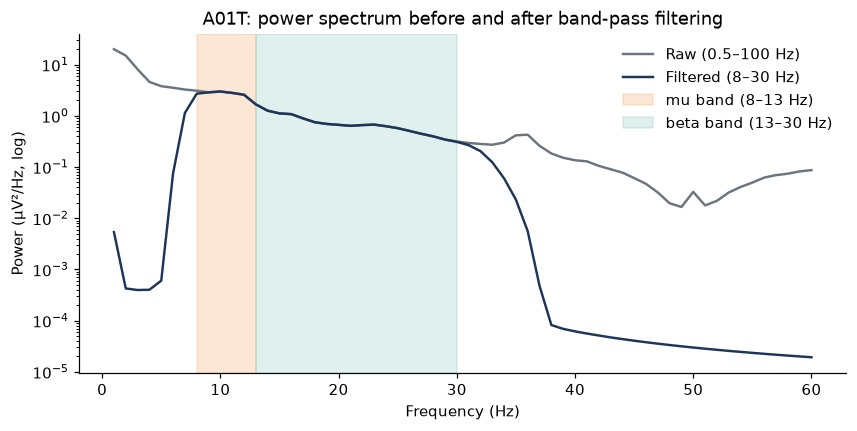

In [5]:
psd_before = make_epochs(raw_eeg).compute_psd(method="welch", fmin=1, fmax=60, n_fft=250).average()
psd_after = make_epochs(raw_filt).compute_psd(method="welch", fmin=1, fmax=60, n_fft=250).average()

fig, ax = plt.subplots(figsize=(9, 4))
for psd, label, color in [(psd_before, "Raw (0.5–100 Hz)", "#6c757d"), (psd_after, "Filtered (8–30 Hz)", "#1d3557")]:
    ax.semilogy(psd.freqs, psd.get_data().mean(axis=0) * 1e12, label=label, color=color, lw=1.6)
ax.axvspan(8, 13, color="#f4a261", alpha=0.25, label="mu band (8–13 Hz)")
ax.axvspan(13, 30, color="#2a9d8f", alpha=0.15, label="beta band (13–30 Hz)")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Power (µV²/Hz, log)")
ax.set_title("A01T: power spectrum before and after band-pass filtering")
ax.legend(frameon=False)
fig.savefig(FIG_DIR / "02_psd_before_after.png", bbox_inches="tight")
plt.show()

## C. Epoching
Cut one window per trial, from the **cue (t = 2 s) to 4 s later (t = 6 s)**. That is the period when the subject performs the motor imagery.

At 250 Hz, 4 s = **1000 samples**, so each trial becomes a **22 × 1000** matrix.

In [6]:
epochs = make_epochs(raw_filt)
X = epochs.get_data() * 1e6          # volts -> microvolts
y = epochs.events[:, 2]

print(f"X shape : {X.shape}   (trials, channels, time samples)")
print(f"y shape : {y.shape}")
print(f"Window  : {TMIN:.0f}–{TMAX:.0f} s after cue = {X.shape[2]} samples at {sf:.0f} Hz")
print(f"Classes : {dict(zip(CLASS_NAMES, np.bincount(y)))}")

X shape : (288, 22, 1000)   (trials, channels, time samples)
y shape : (288,)
Window  : 0–4 s after cue = 1000 samples at 250 Hz
Classes : {'left_hand': np.int64(72), 'right_hand': np.int64(72), 'feet': np.int64(72), 'tongue': np.int64(72)}


## Sanity check: can we see motor imagery in the data?
Neuroscience predicts that imagining a hand movement **reduces mu-band power over the opposite hemisphere** (ERD):
- **right hand** imagery → power drop at **C3** (left hemisphere)
- **left hand** imagery → power drop at **C4** (right hemisphere)

Below: mu-band (8–13 Hz) power over time, averaged across trials, as % change from the pre-cue baseline. If the data behaves as expected, the model has a real signal to learn from.

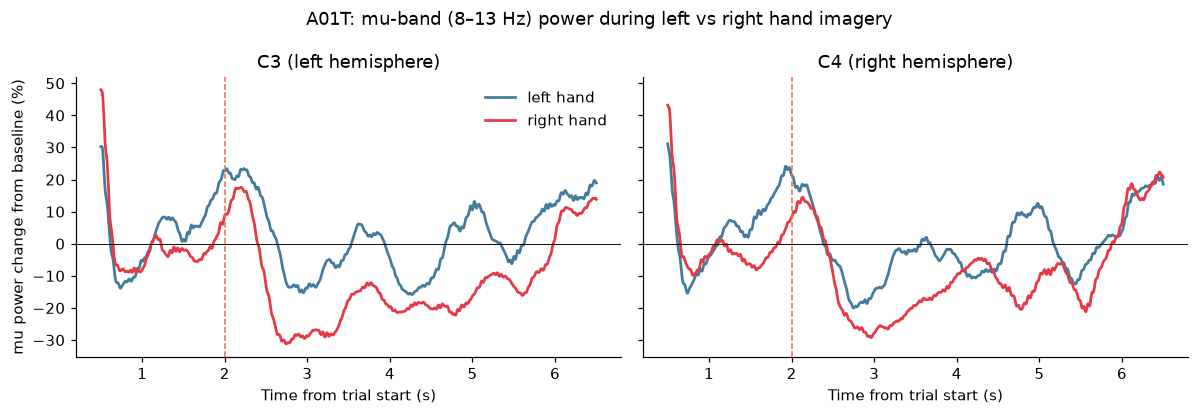

C3: mean mu change 3–6 s  -> left hand -1.3%, right hand -17.0%
C4: mean mu change 3–6 s  -> left hand -2.5%, right hand -13.4%


In [7]:
raw_mu = raw_eeg.copy().filter(8, 13)
ev_all, ev_id = cue_events(raw_mu)
ep = mne.Epochs(raw_mu, ev_all, ev_id, tmin=-2.0, tmax=5.0, baseline=None, preload=True, picks=["C3", "C4"])
power = ep.get_data() ** 2                                        # instantaneous power
k = int(0.5 * sf); power = np.apply_along_axis(lambda s: np.convolve(s, np.ones(k) / k, "same"), 2, power)
keep = (ep.times >= -1.5) & (ep.times <= 4.5)                     # drop smoothing edge effects
power = power[:, :, keep]
times = ep.times[keep] + 2                                        # time from trial start (0.5–6.5 s)
base = (times >= 0.5) & (times <= 1.5)                            # pre-cue baseline (fixation period)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, ch_i, ch in zip(axes, [0, 1], ["C3", "C4"]):
    for cls, color in [("left_hand", "#457b9d"), ("right_hand", "#e63946")]:
        p = power[ep.events[:, 2] == ev_id[cls], ch_i].mean(axis=0)
        erd = 100 * (p - p[base].mean()) / p[base].mean()
        ax.plot(times, erd, color=color, lw=1.8, label=cls.replace("_", " "))
    ax.axhline(0, color="black", lw=0.6); ax.axvline(2, color="#e76f51", ls="--", lw=1)
    ax.set_title(f"{ch} ({'left' if ch == 'C3' else 'right'} hemisphere)")
    ax.set_xlabel("Time from trial start (s)")
axes[0].set_ylabel("mu power change from baseline (%)"); axes[0].legend(frameon=False)
fig.suptitle("A01T: mu-band (8–13 Hz) power during left vs right hand imagery")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_erd_c3_c4.png", bbox_inches="tight")
plt.show()

win = (times >= 3) & (times <= 6)
for ch_i, ch in enumerate(["C3", "C4"]):
    vals = {}
    for cls in ["left_hand", "right_hand"]:
        p = power[ep.events[:, 2] == ev_id[cls], ch_i].mean(axis=0)
        vals[cls] = 100 * (p[win].mean() - p[base].mean()) / p[base].mean()
    print(f"{ch}: mean mu change 3–6 s  -> left hand {vals['left_hand']:+.1f}%, right hand {vals['right_hand']:+.1f}%")

**Reading the plot:**
- **C3 behaves as expected.** Right-hand imagery lowers mu power by about 17% during 3–6 s, while left-hand imagery barely changes it (about 1%). This is the classic contralateral ERD.
- **C4 does not show the mirror image for this subject.** Right-hand imagery also lowers mu power there. Lateralization differs between people and between hemispheres, which is exactly why a learned model (EEGNet) is used rather than a hand-made rule.
- The rise just before and at the cue (≈2 s) is the brain's response to the visual cue. The spike at the very start (≈0.5 s) follows the trial-start beep. Neither is motor imagery.

**Conclusion:** the preprocessed data contains a real, class-dependent motor-imagery signal for the model to learn.

## Run the pipeline for all 9 subjects
The same three steps are applied to every training session and saved to `data_processed/` for Step 3.

In [8]:
rows = []
for subject, session, Xs, ys in save_all(sessions=("T",)):
    rows.append({"subject": subject, "session": session, "X shape": str(Xs.shape),
                 **dict(zip(CLASS_NAMES, np.bincount(ys, minlength=4))),
                 "std (µV)": round(float(Xs.std()), 2)})
processed = pd.DataFrame(rows)
processed

,subject,session,X shape,left_hand,right_hand,feet,tongue,std (µV)
0,A01,T,"(288, 22, 1000)",72,72,72,72,5.43
1,A02,T,"(288, 22, 1000)",72,72,72,72,5.53
2,A03,T,"(288, 22, 1000)",72,72,72,72,7.43
3,A04,T,"(288, 22, 1000)",72,72,72,72,4.98
4,A05,T,"(288, 22, 1000)",72,72,72,72,4.19
5,A06,T,"(288, 22, 1000)",72,72,72,72,7.62
6,A07,T,"(288, 22, 1000)",72,72,72,72,4.81
7,A08,T,"(288, 22, 1000)",72,72,72,72,9.44
8,A09,T,"(288, 22, 1000)",72,72,72,72,9.88


In [9]:
total = sum(int(s.strip("()").split(",")[0]) for s in processed["X shape"])
print(f"Total preprocessed trials: {total}  (9 subjects × 288)")
print(f"Signal std ranges from {processed['std (µV)'].min()} to {processed['std (µV)'].max()} µV across subjects,")
print("a first visible sign of how differently EEG behaves from person to person.")

Total preprocessed trials: 2592  (9 subjects × 288)
Signal std ranges from 4.19 to 9.88 µV across subjects,
a first visible sign of how differently EEG behaves from person to person.


## Summary

| Step | What we did | Result |
|---|---|---|
| A. Remove EOG | kept only the 22 EEG channels | 25 → 22 channels |
| B. Band-pass 8–30 Hz | zero-phase FIR filter on the continuous signal | mu + beta kept; drifts, muscle noise and 50 Hz removed |
| C. Epoching | 0–4 s after each cue (trial time 2–6 s) | **288 × 22 × 1000** per subject |
| All subjects | same pipeline on the 9 training sessions | **2,592 trials** saved in `data_processed/` |

**Observations**
- The filtered spectrum keeps the clear **mu peak around 10 Hz**. That is the rhythm motor imagery modulates.
- The sanity check shows a **real motor-imagery effect** (right-hand ERD at C3) in the preprocessed data.
- Signal amplitude differs between subjects (**std 4.2–9.9 µV**). This is the kind of between-subject difference that Euclidean Alignment will address later.

**Design choices (to revisit later)**
- All trials are kept, including the expert-marked artifact trials, following Nzakuna et al. (2025).
- Junqueira et al. (2024) used a similar 8–32 Hz band. Nzakuna et al. used no extra filter. 8–30 Hz is a standard choice focused on sensorimotor rhythms.

**Next: Step 3, the EEGNet baseline**, trained on these preprocessed trials.